# Vehicle Detection

### Import Libraries:

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

In [6]:
# Folder Structure
parent_dir = "vehicle_detection"

train_dir = os.path.join(parent_dir, "train")
test_dir = os.path.join(parent_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Folders created successfully")

Folders created successfully


### Unzip Dataset:

In [23]:
import os
os.listdir("vehicle_detection")

['Images', 'test', 'train']

### step 4:

In [16]:
import os

os.listdir()

['.ipynb_checkpoints',
 'dataset_folder',
 'destination_folder',
 'Images',
 'Images.rar',
 'IMG',
 'labels.csv',
 'Tesla - Deaths.csv',
 'Vehicle Detection.ipynb',
 'vehicle_detection']

In [19]:
import os
os.listdir("Images")

['00000000.jpg',
 '00000001.jpg',
 '00000002.jpg',
 '00000003.jpg',
 '00000004.jpg',
 '00000005.jpg',
 '00000006.jpg',
 '00000007.jpg',
 '00000008.jpg',
 '00000009.jpg',
 '00000010.jpg',
 '00000011.jpg',
 '00000012.jpg',
 '00000013.jpg',
 '00000014.jpg',
 '00000015.jpg',
 '00000016.jpg',
 '00000017.jpg',
 '00000018.jpg',
 '00000019.jpg',
 '00000020.jpg',
 '00000021.jpg',
 '00000022.jpg',
 '00000023.jpg',
 '00000024.jpg',
 '00000025.jpg',
 '00000026.jpg',
 '00000027.jpg',
 '00000028.jpg',
 '00000029.jpg',
 '00000030.jpg',
 '00000031.jpg',
 '00000032.jpg',
 '00000033.jpg',
 '00000034.jpg',
 '00000035.jpg',
 '00000036.jpg',
 '00000037.jpg',
 '00000038.jpg',
 '00000039.jpg',
 '00000040.jpg',
 '00000041.jpg',
 '00000042.jpg',
 '00000043.jpg',
 '00000044.jpg',
 '00000045.jpg',
 '00000046.jpg',
 '00000047.jpg',
 '00000048.jpg',
 '00000049.jpg',
 '00000050.jpg',
 '00000051.jpg',
 '00000052.jpg',
 '00000053.jpg',
 '00000054.jpg',
 '00000055.jpg',
 '00000056.jpg',
 '00000057.jpg',
 '00000058.jpg

In [22]:
import os

for root, dirs, files in os.walk("Images"):
    print("PATH:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("------")

PATH: Images
DIRS: []
FILES: ['00000000.jpg', '00000001.jpg', '00000002.jpg', '00000003.jpg', '00000004.jpg']
------


In [21]:
# Cell 4 (FINAL WORKING)
IMG_SIZE = 128

def load_images(folder):
    images = []
    labels = []
    
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            images.append(image)
            labels.append("vehicle")   # single class
        except:
            pass
    
    return np.array(images), np.array(labels)

images, labels = load_images("Images")

In [24]:
print(set(labels))

{np.str_('vehicle')}


### Convert Labels:

In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
labels = encoder.fit_transform(labels)

labels = tf.keras.utils.to_categorical(labels)

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Train Test Split:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (4500, 128, 128, 3)
Testing shape: (1125, 128, 128, 3)


### Build CNN Model:

In [27]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(labels.shape[1], activation='softmax'))

model.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Model:

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model:

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 558ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 568ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 75s 530ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 536ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 77s 549ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 76s 541ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 74s 527ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━

### Evaluate Model:

In [31]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0


### Plot Accuracy Graph:

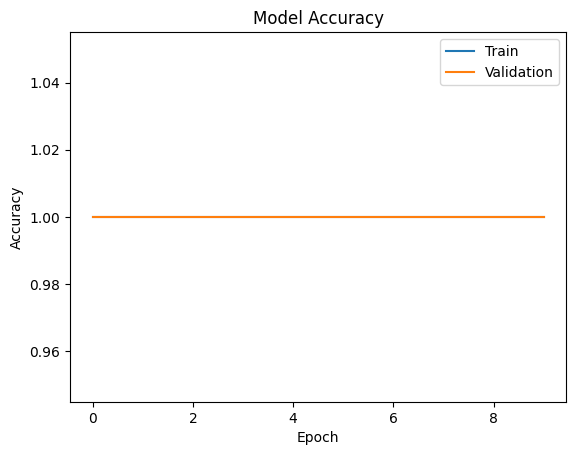

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

### Run Inference on Sample Image:

In [34]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    
    if img is None:
        print("Image not found. Check path.")
        return
    
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))
    
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    
    print("Detected Vehicle:", encoder.inverse_transform([class_index]))

# use real image
predict_image("Images/00000000.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
Detected Vehicle: ['vehicle']


### Save Model:

In [35]:
model.save("vehicle_detection_model.h5")
print("Model saved successfully")

Model saved successfully
